In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [8]:
# ==========================
# 1️⃣ Load and Preprocess Data
# ==========================
def load_dataset(directory, img_size=(64, 64)):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), classes

# Load training dataset
TRAIN_DIR = "Brain_Tumor_data/Training"
X, y, class_names = load_dataset(TRAIN_DIR)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=len(class_names))
print(f"[INFO] Loaded {len(X)} images across {len(class_names)} classes: {class_names}")

[INFO] Loaded 5712 images across 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
# ==========================
# 2️⃣ Define CNN Model Architecture
# ==========================
def build_cnn(input_shape, num_classes):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 4
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [4]:

# ==========================
# 3️⃣ K-Fold Cross Validation (5 folds × 30 epochs)
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
fold_accuracies = []

for train_index, val_index in kf.split(X):
    print(f"\n[INFO] Training Fold {fold_no} / 5 ...")
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y_cat[train_index], y_cat[val_index]

    model = build_cnn((64, 64, 3), len(class_names))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,             # equivalent to FL total rounds × local epochs
        batch_size=16,
        verbose=1
    )

    acc = np.max(history.history['val_accuracy'])
    fold_accuracies.append(acc)
    model.save(f"classical_cnn_fold{fold_no}.keras")
    print(f"[INFO] Fold {fold_no} Accuracy: {acc:.4f}")
    fold_no += 1

mean_acc = np.mean(fold_accuracies)
print(f"\n✅ Mean K-Fold Validation Accuracy: {mean_acc:.4f}")
model.save("classical_cnn_complete.keras")
print("[✓] Saved final model: classical_cnn_complete.keras")


[INFO] Training Fold 1 / 5 ...


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761771483.815447    3971 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/30


2025-10-29 20:58:11.297233: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe5d800de00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-29 20:58:11.297265: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-10-29 20:58:11.634481: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-29 20:58:12.718017: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
I0000 00:00:1761771508.113293    4644 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


286/286 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - accuracy: 0.6367 - loss: 1.0613 - val_accuracy: 0.2633 - val_loss: 3.2631
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7551 - loss: 0.6801 - val_accuracy: 0.4191 - val_loss: 3.1132
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8037 - loss: 0.5318 - val_accuracy: 0.8233 - val_loss: 0.4133
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8264 - loss: 0.4597 - val_accuracy: 0.8224 - val_loss: 0.5406
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8619 - loss: 0.3702 - val_accuracy: 0.8609 - val_loss: 0.3645
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8763 - loss: 0.3444 - val_accuracy: 0.8941 - val_loss: 0.2922
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8888 - loss: 0.3177 - val_accuracy: 0.8801 - val_loss: 0.2937
Epoch 8/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9054 - loss: 0.2627 - val_accuracy: 0.90

In [10]:

# ==========================
# 4️⃣ Evaluate and Visualize (using test set)
# ==========================
import os
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
model = load_model("classical_cnn_complete.keras")

TEST_DIR = "Brain_Tumor_data/Testing"
def load_test_dataset(directory, img_size=(64, 64)):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

X_test, y_test = load_test_dataset(TEST_DIR)
y_test_enc = encoder.transform(y_test)
y_test_cat = to_categorical(y_test_enc, num_classes=len(class_names))

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
print("\n📊 Classification Report:")
print(classification_report(y_test_enc, y_pred))
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))


2025-10-30 01:05:46.300981: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f25200141c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-30 01:05:46.301026: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-10-30 01:05:46.498109: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-30 01:05:46.886582: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
2025-10-30 01:05:47.730455: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_348', 60 bytes spill stores, 60 bytes spill loads



19/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9512 - loss: 0.1904 

I0000 00:00:1761786353.342490   70571 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9572 - loss: 0.1539

2025-10-30 01:05:54.199306: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_348', 8 bytes spill stores, 8 bytes spill loads

2025-10-30 01:05:54.418400: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_348', 52 bytes spill stores, 52 bytes spill loads



41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.9718 - loss: 0.0885

🎯 Test Accuracy: 0.9718
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       300
           1       0.95      0.94      0.95       306
           2       0.98      1.00      0.99       405
           3       0.99      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311


📊 Confusion Matrix:
[[285  13   0   2]
 [  7 289  10   0]
 [  2   0 403   0]
 [  0   3   0 297]]


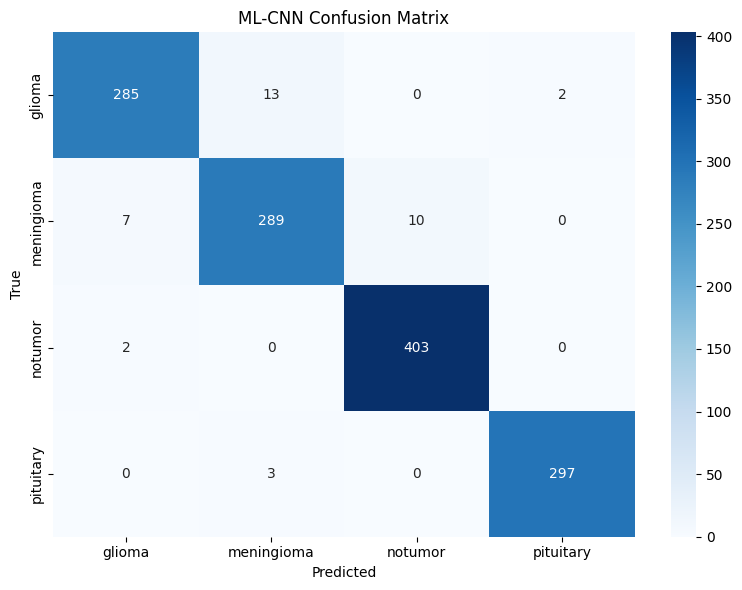

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ML-CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('mlcnn_confusion_matrix.png', dpi=300)
plt.show()

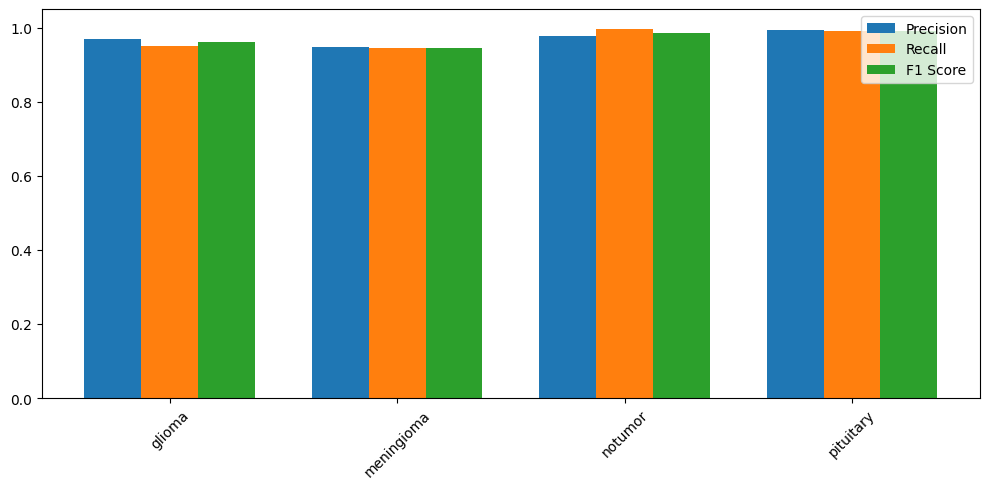

In [7]:
# Precision, Recall, F1
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred, average=None)
x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')
plt.xticks(x, class_names, rotation=45)
plt.ylim([0, 1.05])
plt.legend()
plt.tight_layout()
plt.savefig('mlcnn_performance_metrics.png', dpi=300)
plt.show()

In [8]:
# ==========================
# 5️⃣ Save Results
# ==========================
results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_config': {'img_size': (64, 64, 3), 'num_classes': len(class_names)},
    'kfold_results': {'fold_scores': [float(s) for s in fold_accuracies],
                      'mean_accuracy': float(np.mean(fold_accuracies)),
                      'std_accuracy': float(np.std(fold_accuracies))},
    'test_accuracy': float(test_acc)
}

with open('mlcnn_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print("💾 Saved: mlcnn_results.json")


💾 Saved: mlcnn_results.json


In [9]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 10,220,654 (38.99 MB)

 Trainable params: 3,405,732 (12.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

 Optimizer params: 6,811,466 (25.98 MB)

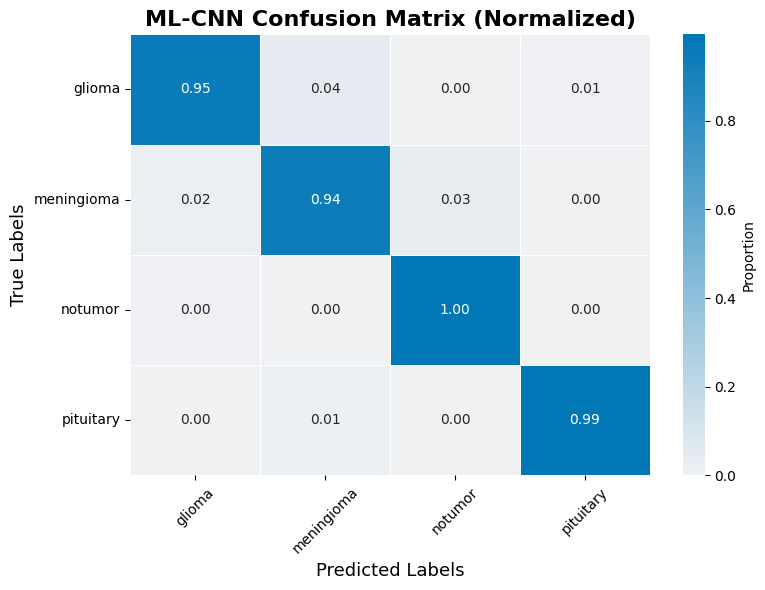

 Saved: ml_cnn_confusion_matrix_gradient.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_gradient_confusion_matrix(y_true, y_pred, class_names, model_name="ML-CNN"):
    cm = confusion_matrix(y_true, y_pred)
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize

    plt.figure(figsize=(8,6))
    cmap = sns.light_palette("#0077b6", as_cmap=True)  # ocean blue gradient
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar_kws={"label": "Proportion"})

    plt.title(f"{model_name} Confusion Matrix (Normalized)", fontsize=16, fontweight='bold')
    plt.xlabel("Predicted Labels", fontsize=13)
    plt.ylabel("True Labels", fontsize=13)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    filename = f"{model_name.lower().replace('-','_')}_confusion_matrix_gradient.png"
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f" Saved: {filename}")
plot_gradient_confusion_matrix(y_test_enc, y_pred, class_names, model_name="ML-CNN")    

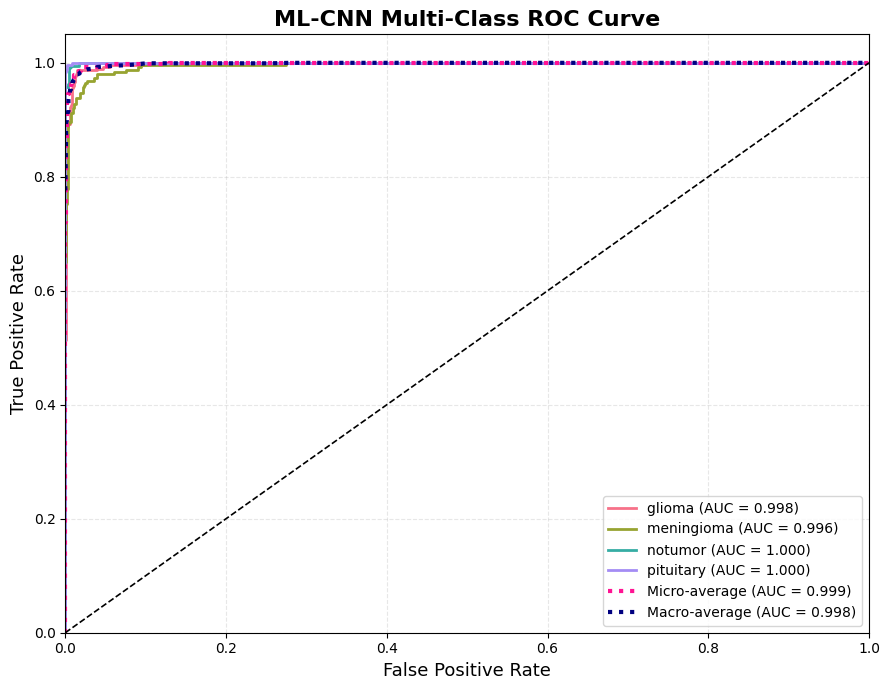

✅ Saved: ml_cnn_multiclass_roc.png


In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_multiclass_roc(y_true, y_pred_probs, class_names, model_name="ML-CNN"):
    # Binarize true labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = y_true_bin.shape[1]

    # Compute ROC curve and AUC for each class
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # ==== PLOT ====
    plt.figure(figsize=(9,7))
    colors = sns.color_palette("husl", n_classes)
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")
    plt.plot(fpr["micro"], tpr["micro"],
             label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
             color="deeppink", linestyle=':', linewidth=3)
    plt.plot(fpr["macro"], tpr["macro"],
             label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
             color="navy", linestyle=':', linewidth=3)
    plt.plot([0,1], [0,1], 'k--', lw=1.2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title(f"{model_name} Multi-Class ROC Curve", fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10, frameon=True)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    filename = f"{model_name.lower().replace('-','_')}_multiclass_roc.png"
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")
plot_multiclass_roc(y_test_enc, y_pred_probs, class_names, model_name="ML-CNN") 

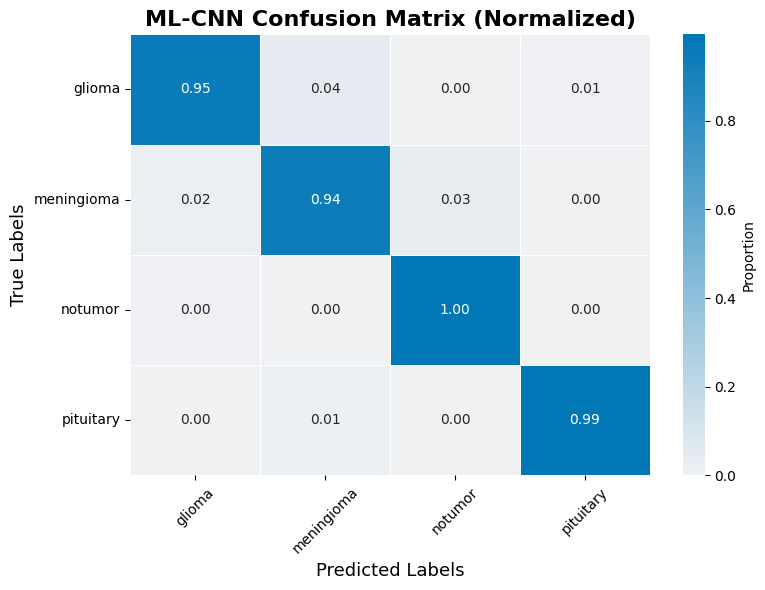

 Saved: ml_cnn_confusion_matrix_gradient.png


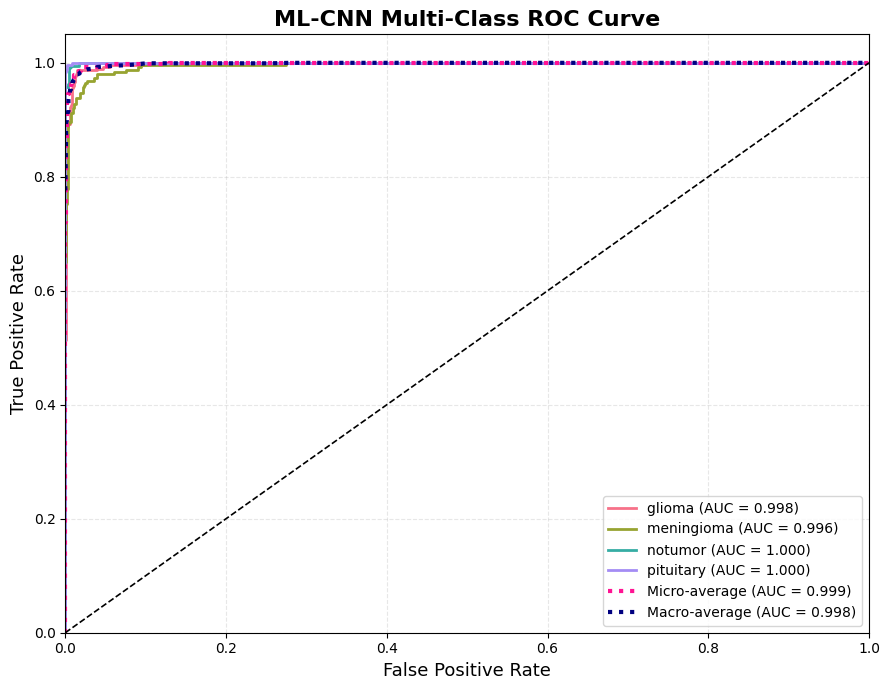

✅ Saved: ml_cnn_multiclass_roc.png


: 

In [ ]:
plot_gradient_confusion_matrix(y_test_enc, y_pred, class_names, model_name="ML-CNN")
plot_multiclass_roc(y_test_enc, y_pred_probs, class_names, model_name="ML-CNN")